In [3]:
import kagglehub

path = kagglehub.dataset_download("nelgiriyewithana/new-york-housing-market")

print("Path to dataset files: ", path)

c:\Users\aravn\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files:  C:\Users\aravn\.cache\kagglehub\datasets\nelgiriyewithana\new-york-housing-market\versions\1


In [13]:
import os
import pandas as pd

print(path)
print(os.listdir(path))

csv_path = os.path.join(path, "NY-House-Dataset.csv")
df = pd.read_csv(csv_path)
df.head()

C:\Users\aravn\.cache\kagglehub\datasets\nelgiriyewithana\new-york-housing-market\versions\1
['.venv', 'NY-House-Dataset.csv']


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [14]:
X = df[['BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE',
        'STATE', 'LOCALITY', 'SUBLOCALITY', 'TYPE']]

y = df['PRICE']

print(X.head())
print(y.head())

   BEDS       BATH  PROPERTYSQFT   LATITUDE  LONGITUDE  \
0     2   2.000000        1400.0  40.761255 -73.974483   
1     7  10.000000       17545.0  40.766393 -73.980991   
2     4   2.000000        2015.0  40.541805 -74.196109   
3     3   1.000000         445.0  40.761398 -73.974613   
4     7   2.373861       14175.0  40.767224 -73.969856   

                     STATE  LOCALITY      SUBLOCALITY                TYPE  
0       New York, NY 10022  New York        Manhattan      Condo for sale  
1       New York, NY 10019  New York  New York County      Condo for sale  
2  Staten Island, NY 10312  New York  Richmond County      House for sale  
3      Manhattan, NY 10022  New York  New York County      Condo for sale  
4       New York, NY 10065  New York  New York County  Townhouse for sale  
0       315000
1    195000000
2       260000
3        69000
4     55000000
Name: PRICE, dtype: int64


In [15]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

categorical_features = ['STATE', 'LOCALITY', 'SUBLOCALITY', 'TYPE']
numeric_features = ['BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE']

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Final shape after preprocessing: ", X_train_processed.shape)

Final shape after preprocessing:  (3840, 341)


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(n_estimators = 500, max_depth = 20, random_state = 42)
rf.fit(X_train_processed, y_train)
y_pred = rf.predict(X_test_processed)
r2 = r2_score(y_test, y_pred)
print("Random Forest R^2:", r2)

Random Forest R^2: 0.6483848362719387


In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

X = X.copy()

X['PRICE_PER_SQFT'] = y / X['PROPERTYSQFT'].replace(0,1)
X['BED_BATH_RATIO'] = X['BEDS'] / X['BATH'].replace(0,1)
X['PRICE_PER_SQFT'] = X['PRICE_PER_SQFT'].clip(upper=1e6)
X['BED_BATH_RATIO'] = X['BED_BATH_RATIO'].clip(upper=1e6)

coords = X[['LATITUDE', 'LONGITUDE']]
kmeans = KMeans(n_clusters = 20, random_state = 42)
X['LOCATION_CLUSTER'] = kmeans.fit_predict(coords)

def reduce_categories(series, top_n=20):
    top_categories = series.value_counts().nlargest(top_n).index
    return series.apply(lambda x: x if x in top_categories else 'Other')

X['LOCALITY'] = reduce_categories(X['LOCALITY'], top_n=20)
X['SUBLOCALITY'] = reduce_categories(X['SUBLOCALITY'], top_n=20)

categorical_features = ['STATE', 'LOCALITY', 'SUBLOCALITY', 'TYPE', 'LOCATION_CLUSTER']
numeric_features = ['BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE', 'PRICE_PER_SQFT', 'BED_BATH_RATIO']

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
rf = RandomForestRegressor(n_estimators = 500, max_depth = 20, random_state = 42)
rf.fit(X_train_processed, y_train)
y_pred = rf.predict(X_test_processed)
r2 = r2_score(y_test, y_pred)
print("Random Forest R^2:", r2)

Random Forest R^2: 0.9299435761960398


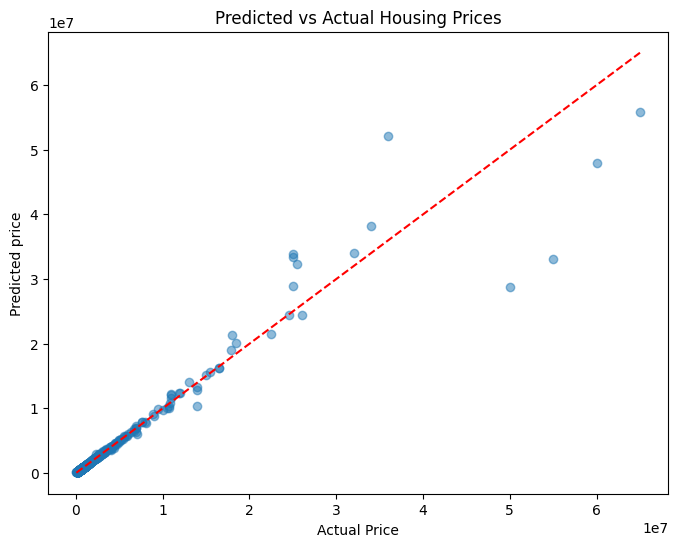

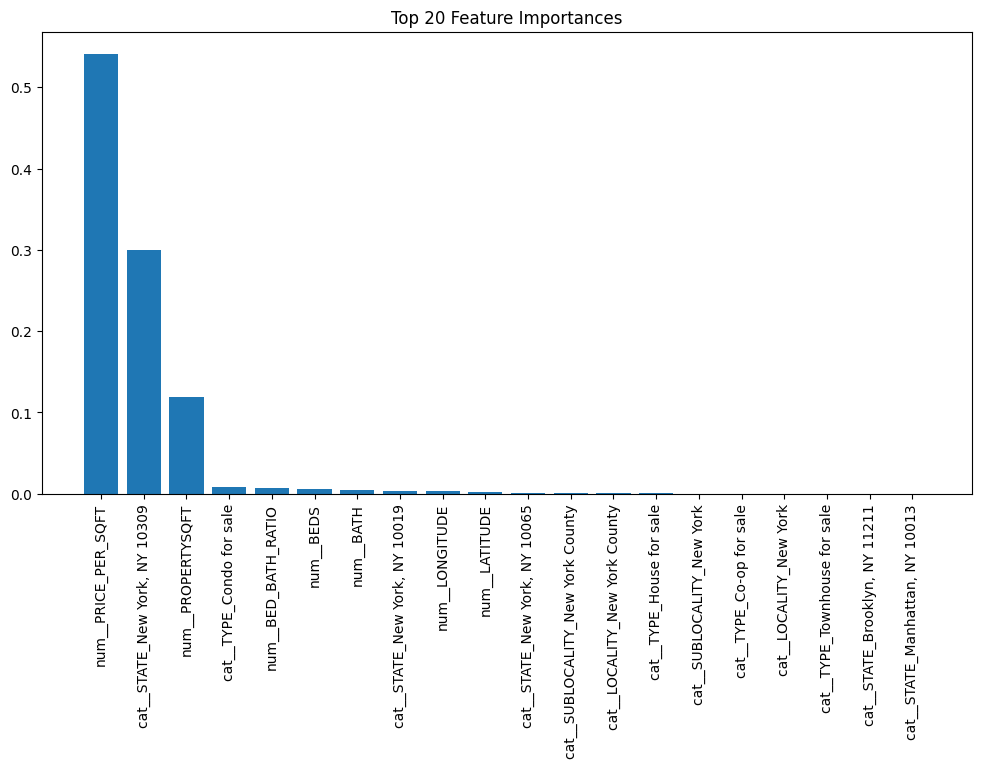

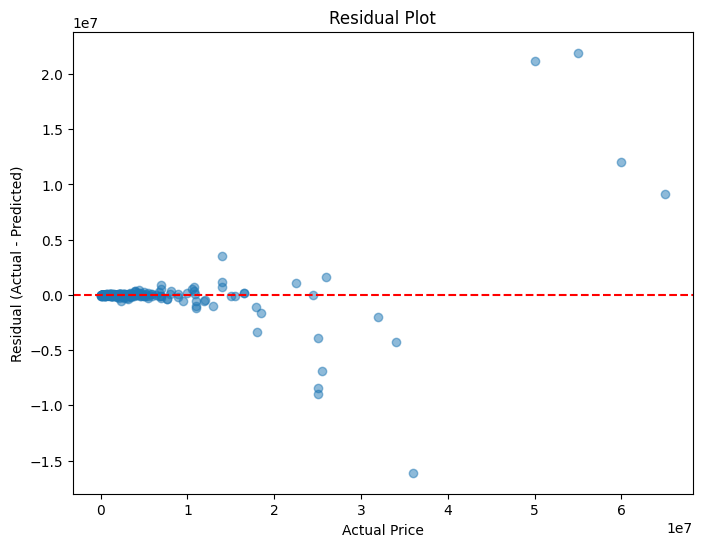

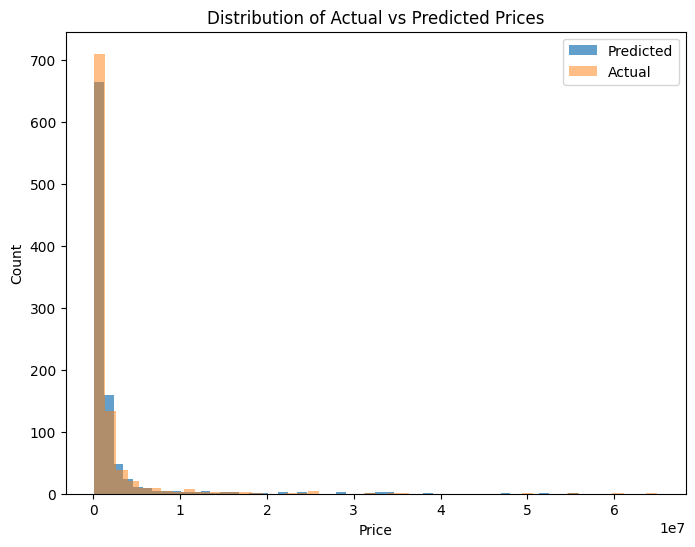

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted price")
plt.title("Predicted vs Actual Housing Prices")
plt.show()

import numpy as np

importances = rf.feature_importances_
feature_names = preprocessor.get_feature_names_out()
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices][:20], align='center')
plt.xticks(range(20), feature_names[indices][:20], rotation=90)
plt.title("Top 20 Feature Importances")
plt.show()


residuals = y_test - y_pred


plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()


plt.figure(figsize=(8, 6))
plt.hist(y_pred, bins=50, alpha=0.7, label='Predicted')
plt.hist(y_test, bins=50, alpha=0.5, label='Actual')
plt.xlabel("Price")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of Actual vs Predicted Prices")
plt.show()